In [1]:
from config.llm import llm

from typing import TypedDict

/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_key is not default parameter.
                openai_api_key was transferred to model_kwargs.
                Please confirm that openai_api_key is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_base is not default parameter.
                openai_api_base was transferred to model_kwargs.
                Please confirm that openai_api_base is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
class EmailClassification(TypedDict):
  intent: str
  urgency: str
  topic: str
  summary: str
  
class EmailAgentState(TypedDict):
  email_content: str
  sender_email: str
  email_id: str
  
  classification: EmailClassification | None
  
  search_results: list[str] | None
  
  draft_response: str | None

In [19]:
# 读邮件节点
def read_email(state: EmailAgentState): 
  """读取并解析邮件内容"""
  # 实际项目这里对接邮件服务 API
  print(f"📧 收到邮件：{state['email_content'][:50]}...")
  return {}

In [11]:
# 分类意图节点

from langgraph.types import Command
import json

def classify_intent(state: EmailAgentState) -> Command:
  """用 LLM 分类邮件，然后决定走哪条路"""
  
  prompt = (
    "分析下面这封客户邮件，返回 json 格式的分类结果。\n"
     "字段：intent(question/bug/billing/feature/complex), "
        "urgency(low/medium/high/critical), topic(话题), summary(总结)\n"
        "只返回 JSON，不要其他内容。\n\n"
        f"邮件：{state['email_content']}\n发件人：{state['sender_email']}"
  )
  
  response = llm.invoke(['human', prompt])
  
  # 解析json
  try: 
    text = response.content.strip()
    if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
    classification = json.loads(text.strip())
  except (json.JSONDecodeError, IndexError):
    # 解析失败，当作复杂问题处理
    classification = {
        "intent": "complex", "urgency": "medium",
        "topic": "unknown", "summary": state["email_content"][:100]
    } 
    
  print(f"📋 分类结果：intent={classification.get('intent')}, "
          f"urgency={classification.get('urgency')}") 
  
  intent = classification.get('intent', 'complex')
  if intent in ['question', 'feature', 'billing']:
    goto = 'search_documentation'
  elif intent == 'bug':
    goto = 'bug_tracking'
  else:
    goto = 'draft_response'
    
  return Command(update={"classification": classification}, goto=goto) 

In [12]:
def search_documentation(state: EmailAgentState) -> Command:
  """搜索知识库找相关文档"""
  topic = state.get('classification', {}).get('topic', "")
  email = state.get('email_content', "").lower()
  
  # 实际项目对接你的知识库/向量数据库
  # 这里用模拟数据演示
  mock_docs = {
        "password": ["重置密码：设置 → 安全 → 修改密码",
                     "密码要求：至少12位，包含大小写和数字"],
        "密码": ["重置密码：设置 → 安全 → 修改密码",
                "密码要求：至少12位，包含大小写和数字"],
        "billing": ["退款流程：提交工单后3-5个工作日处理",
                    "重复扣款：系统自动检测并退还多余费用"],
        "扣款": ["退款流程：提交工单后3-5个工作日处理",
                "重复扣款：系统自动检测并退还多余费用"],
        "订阅": ["退款流程：提交工单后3-5个工作日处理",
                "重复扣款：系统自动检测并退还多余费用"],
        "dark": ["深色模式已在开发计划中", "预计下个版本发布"],
        "深色": ["深色模式已在开发计划中", "预计下个版本发布"],
  }
  results = []
  
  for key, docs in mock_docs.items():
    if key in topic.lower() or key in email:
      results.extend(docs)
  results = list(dict.fromkeys(results)) 
  
  if not results:
    results = ['not found']
    
  print(f"🔍 搜索到 {len(results)} 条相关文档")
  
  return  Command(update={"search_results": results}, goto="draft_response")

In [13]:
def bug_tracking(state: EmailAgentState) -> Command:
  """创建 bug 工单"""
  # 实际项目对接jira
  
  ticket_id = "BUG-" + state.get('email_id', '000')[-3:]
  print(f"🐛 创建了 Bug 工单：{ticket_id}")

  return Command(
       update={"search_results": [f"已创建 Bug 工单 {ticket_id}，技术团队会尽快处理"]},
        goto="draft_response"
  )

In [ ]:
def read_email(state: EmailAgentState):
    """读取并解析邮件内容。"""
    # 实际项目里这里对接邮件服务 API
    print(f"📧 收到邮件：{state['email_content'][:50]}...")
    return {}

In [14]:
def draft_response(state: EmailAgentState) -> Command:
  """生成回复草稿，根据意图和紧急程度决定走人工审核还是直接发送"""
  
  classification = state.get('classification', {})
  
  # 在节点里面按需格式化，而不是存在状态里
  context = ""
  if state.get("search_results", ""):
    context = "参考资料：\n" + "\n".join(
            f"- {doc}" for doc in state["search_results"]
    )
  prompt = (
    f"为这封客户邮件写回复：\n{state['email_content']}\n"
        f"类型：{classification.get('intent', '未知')}\n"
        f"紧急程度：{classification.get('urgency', '中')}\n"
        f"{context}\n"
        "要求：专业友好，针对具体问题，用中文，直接输出回复内容"
  )
  
  response = llm.invoke(['human', prompt])
  # 涉及钱的或极紧急的 → 人工审核，其余直接发
  needs_review = (
    classification.get('urgency') == 'critical' or classification.get('intent') == 'billing'
  )
  
  goto = "human_review" if needs_review else 'send_reply'
  print(f"✍️  回复草稿已生成，{'需要人工审核' if needs_review else '直接发送'}")

  return Command(
        update={"draft_response": response.content},
        goto=goto
  )

In [15]:
from langgraph.types import interrupt

def human_review(state: EmailAgentState) -> Command:
    """暂停等待人工审核。"""
    classification = state.get("classification", {})

    # interrupt() 会暂停图的执行，把上下文展示给人工
    human_decision = interrupt({
        "email_id": state.get("email_id", ""),
        "original_email": state.get("email_content", ""),
        "draft_response": state.get("draft_response", ""),
        "urgency": classification.get("urgency"),
        "action": "请审核这封回复，approved=True 表示通过"
    })

    # 人工传回结果后，从这里继续跑
    if human_decision.get("approved"):
        # 人工可能修改了回复内容
        edited = human_decision.get("edited_response",
                                    state.get("draft_response", ""))
        print("✅ 人工审核通过")
        return Command(
            update={"draft_response": edited},
            goto="send_reply"
        )
    else:
        print("❌ 人工拒绝，由人工自行处理")
        return Command(update={}, goto="__end__")

In [16]:
def send_reply(state: EmailAgentState):
    """发送邮件回复。"""
    # 实际项目对接邮件服务
    print(f"📤 回复已发送给 {state['sender_email']}")
    return {}

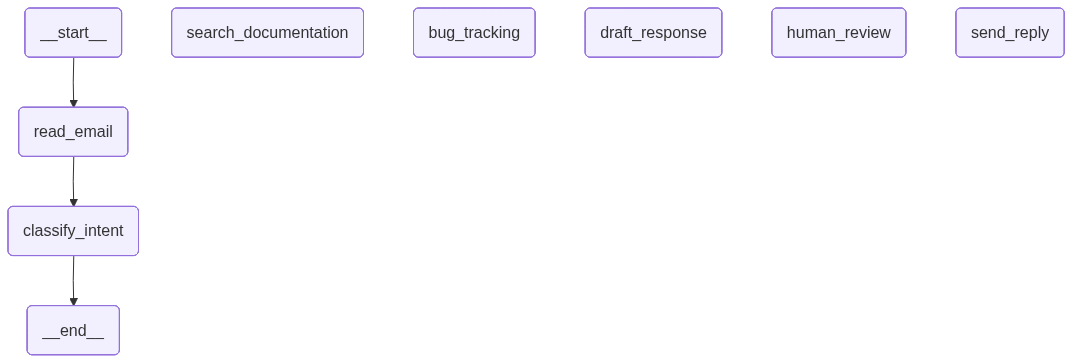

In [21]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

graph_builder = StateGraph(EmailAgentState)

# 添加所有节点
graph_builder.add_node("read_email", read_email)
graph_builder.add_node("classify_intent", classify_intent)
graph_builder.add_node("search_documentation", search_documentation)
graph_builder.add_node("bug_tracking", bug_tracking)
graph_builder.add_node("draft_response", draft_response)
graph_builder.add_node("human_review", human_review)
graph_builder.add_node("send_reply", send_reply)

# 连边——只需要三条！
graph_builder.add_edge(START, "read_email")
graph_builder.add_edge("read_email", "classify_intent")
graph_builder.add_edge("send_reply", END)

# MemorySaver 做 checkpointer，interrupt() 需要它来保存状态
memory = MemorySaver()
app = graph_builder.compile(checkpointer=memory)

app

In [22]:
result = app.invoke(
    {
        "email_content": "你好，请问怎么重置密码？谢谢",
        "sender_email": "zhangsan@example.com",
        "email_id": "email_001",
    },
    config={"configurable": {"thread_id": "test_001"}}
)

📧 收到邮件：你好，请问怎么重置密码？谢谢...
📋 分类结果：intent=question, urgency=low
🔍 搜索到 2 条相关文档
✍️  回复草稿已生成，直接发送
📤 回复已发送给 zhangsan@example.com


In [23]:
result = app.invoke(
    {
        "email_content": "我被扣了两次订阅费！这很紧急，请立刻处理！",
        "sender_email": "lisi@example.com",
        "email_id": "email_002",
    },
    config={"configurable": {"thread_id": "test_002"}}
)

📧 收到邮件：我被扣了两次订阅费！这很紧急，请立刻处理！...
📋 分类结果：intent=billing, urgency=high
🔍 搜索到 2 条相关文档
✍️  回复草稿已生成，需要人工审核


In [24]:
from langgraph.types import Command

final = app.invoke(
    Command(resume={
        "approved": True,
        "edited_response": "非常抱歉给您造成不便！我们已确认您的账户存在重复扣款，"
                          "退款将在3个工作日内到账。如有其他问题，请随时联系我们。"
    }),
    config={"configurable": {"thread_id": "test_002"}}
)

✅ 人工审核通过
📤 回复已发送给 lisi@example.com


In [ ]:
result = app.invoke(
    {
        "email_content": "导出 PDF 的时候页面直接崩溃了，每次都这样",
        "sender_email": "wangwu@example.com",
        "email_id": "email_003",
    },
    config={"configurable": {"thread_id": "test_003"}}
)

📧 收到邮件：导出 PDF 的时候页面直接崩溃了，每次都这样...


In [ ]:
result = app.invoke(
    {
        "email_content": "能不能加个深色模式？晚上用太刺眼了",
        "sender_email": "zhaoliu@example.com",
        "email_id": "email_004",
    },
    config={"configurable": {"thread_id": "test_004"}}
)